In [76]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.stats import linregress
import seaborn as sns
import matplotlib.animation as animation
from pympler import asizeof

## Exact the same as Bornholdt 2003

In [35]:
weights = torch.empty(10, 10, 3, 3, device="cpu").uniform_(-1,1)

In [36]:
weights[:,:,1,1] = 0

In [37]:
# 2 out of 8 neighbour weights are zero
neighour_zero_fraction = 0.25

In [44]:
positions = [(i,j) for i in range(3) for j in range(3) if (i,j) != (1,1)]

In [49]:
round(8*neighour_zero_fraction)

2

In [46]:
for a in range(weights.shape[0]):
    for b in range(weights.shape[1]):
        idx = torch.randperm(8)[:2]

        for k in idx:
            i,j = positions[k]
            weights[a,b,i,j] = 0

In [62]:
neuron_v=torch.zeros(10, 10)

In [80]:
neuron_v[tuple(torch.randint(0,10,(2,)))] = 1

In [97]:
neuron_v[-1:2, -1:2].shape

torch.Size([0, 0])

In [ ]:
activation_matrix = []
for i in range(neuron_v.shape[0]):
    temp = []
    for j in range(neuron_v.shape[1]):
        activations = torch.zeros(3,3)
        neuron_v[i-1:i+2, j-1:j+2]
        print(activations.shape)
        temp.append(activations)
    activation_matrix.append(temp)


torch.Size([0, 0])
torch.Size([0, 3])
torch.Size([0, 3])
torch.Size([0, 3])
torch.Size([0, 3])
torch.Size([0, 3])
torch.Size([0, 3])
torch.Size([0, 3])
torch.Size([0, 3])
torch.Size([0, 2])
torch.Size([3, 0])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 2])
torch.Size([3, 0])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 2])
torch.Size([3, 0])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 2])
torch.Size([3, 0])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 3])
torch.Size([3, 2])
torch.Size([3, 0])
torch.Size([3, 3])
torch.Size([

In [ ]:
activation_matrix = np.array(activation_matrix)

## Import pkl and plot single runs

In [54]:
K_list = [0.001, 0.01, 0.1, 1, 3, 5, 7]
# N_list = [10, 20, 50, 100]

In [69]:
two_correlation = []
for i in range(10):
    with open(f"/Users/compneuro1/Documents/projects/SOC/results/Ks_repeat/K1_{i}.pkl", 'rb') as f:
        test = pickle.load(f)
    two_correlation.append(test['correlation'])

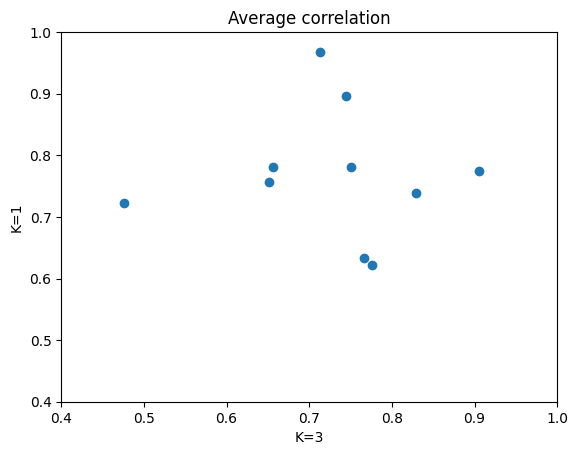

In [80]:
plt.scatter(one_correlation, two_correlation)
plt.xlim(0.4, 1)
plt.ylim(0.4, 1)
plt.xlabel("K=3")
plt.ylabel("K=1")
plt.title("Average correlation")
plt.savefig("noisy_corr.png", dpi=300)

In [217]:
N_list = [10, 20, 50, 100] #, 200, 400, 1000]
activation_list = []
for N in N_list:
    with open(f"/Users/compneuro1/Documents/projects/SOC/N{N}.pkl", "rb") as f:
        test_new= pickle.load(f)
    activations = test_new['activity_list']
    activation_list.append(sum(activations[-30000:])/len(activations[-30000:]))

In [231]:
K_list = [0.001, 0.01, 0.1, 1, 3, 5, 7]
activation_list = []
for K in K_list:
    with open(f"/Users/compneuro1/Documents/projects/SOC/results/Ks_repeat/K{K}_0.pkl", "rb") as f:
        test_new= pickle.load(f)
    activations = test_new['activity_list']
    activation_list.append(sum(activations[-30000:])/len(activations[-30000:]))

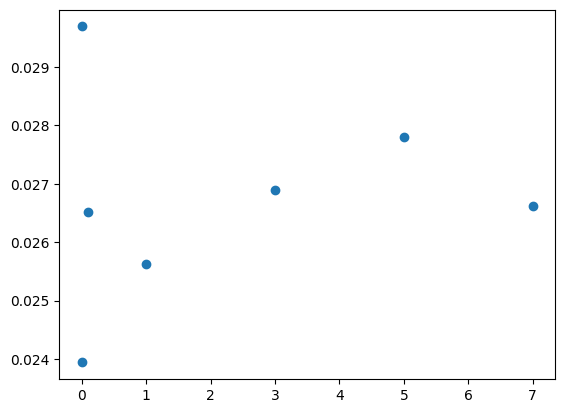

In [232]:
plt.scatter(K_list, activation_list)

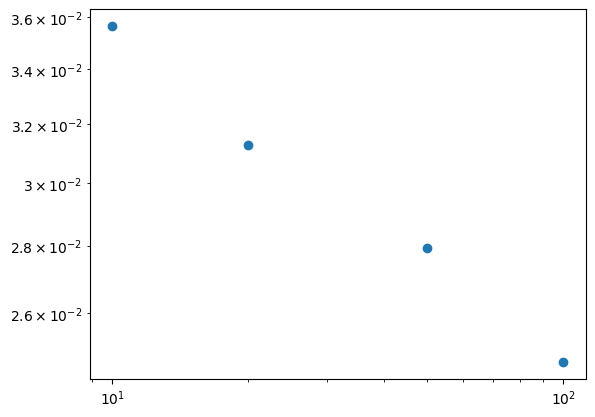

In [ ]:
plt.scatter(N_list, activation_list)
plt.xscale('log')
plt.yscale('log')

# plt.ylim(1e-3, 1e-1)

In [229]:
with open(f"/Users/compneuro1/Documents/projects/SOC/results/Ks_repeat/K3_0.pkl", "rb") as f:
    test_new= pickle.load(f)

Text(0.5, 1.0, 'N200')

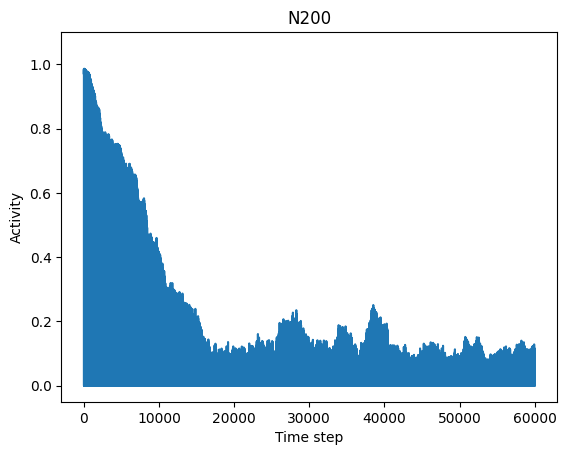

In [230]:
plt.plot(test_new['activity_list'])
plt.ylim(-0.05, 1.1)
plt.xlabel('Time step')
plt.ylabel('Activity')
plt.title('N200')

Text(0.5, 1.0, 'N200')

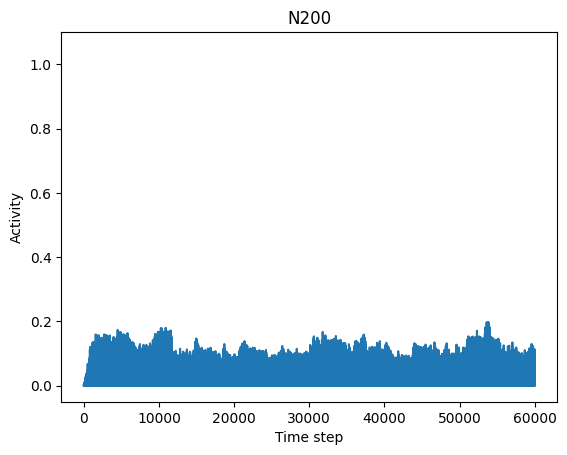

In [226]:
plt.plot(test_new['activity_list'])
plt.ylim(-0.05, 1.1)
plt.xlabel('Time step')
plt.ylabel('Activity')
plt.title('N200')
# plt.savefig('N200_active.png', dpi=300)


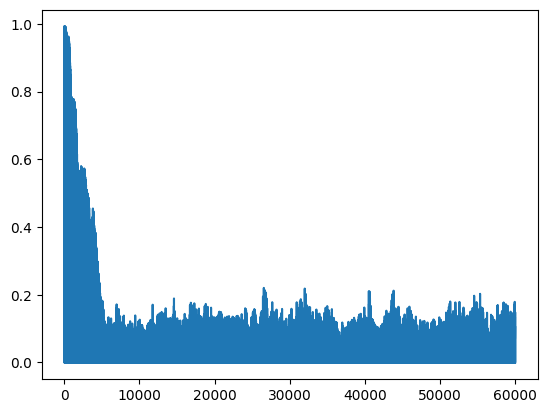

In [166]:
plt.plot(test_new['activity_list'])

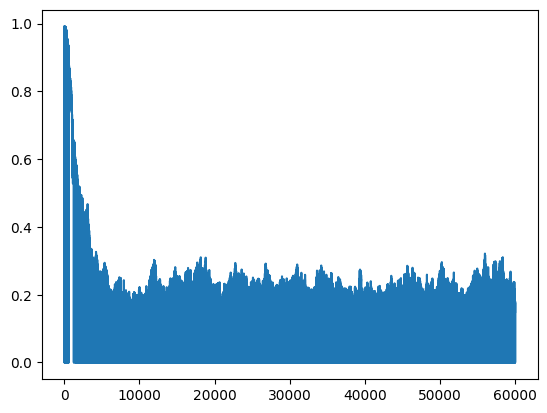

In [168]:
plt.plot(test_new['activity_list'])

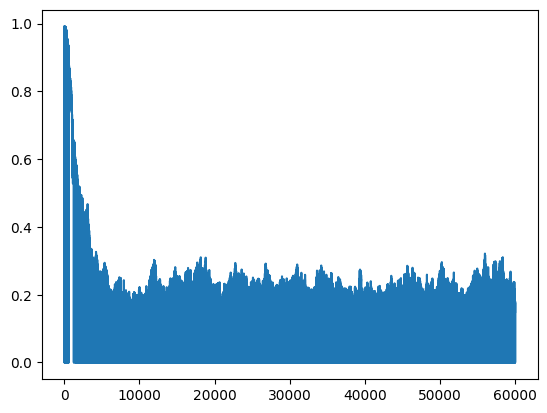

In [160]:
plt.plot(test_new['activity_list'])

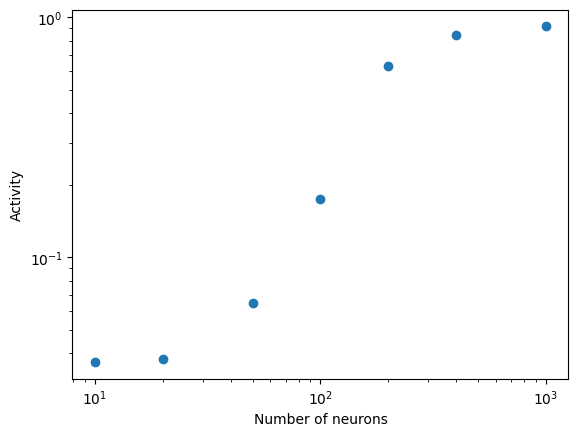

In [174]:
plt.scatter(N_list, activation_list)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of neurons')
plt.ylabel('Activity')
plt.savefig("N_activations.png", dpi=300)

In [155]:
with open(f"/Users/compneuro1/Documents/projects/SOC/results/Ks_repeat/K0.1_0.pkl", "rb") as f:
    test_new= pickle.load(f)

(-0.02, 0.3)

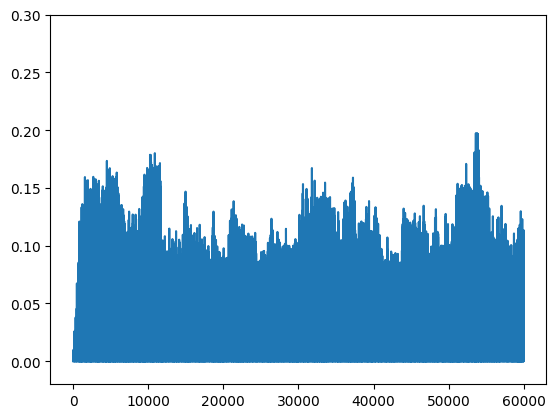

In [156]:
plt.plot(test_new['activity_list'])
plt.ylim(-0.02, 0.3)

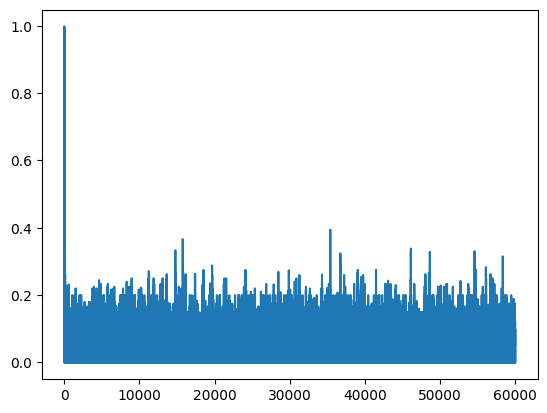

In [132]:
plt.plot(test_new['activity_list'])

In [87]:
activations = test_new['activity_list']
sum(activations)/len(activations)

0.9183420183333326

In [85]:
activations = test_new['activity_list']
sum(activations)/len(activations)

0.037539565490447194

In [64]:
ave_list = []
for K in K_list:
    all_test = []
    for c in range(10):
        with open(f"/Users/compneuro1/Documents/projects/SOC/results/Ks_repeat/K{K}_{c}.pkl", "rb") as f:
            test_new= pickle.load(f)
            all_test.append(test_new)
    correlation_list = []
    activities = []
    for i in all_test:
        correlation_list.append(i['correlation'])
        ave_activity = sum(i['activity_list'])/len(i['activity_list'])
        activities.append(ave_activity)
    ave_list.append(sum(activities)/len(activities))


In [42]:
correlation_list = []
activities = []
for i in all_test:
    correlation_list.append(i['correlation'])
    ave_activity = sum(i['activity_list'])/len(i['activity_list'])
    activities.append(ave_activity)
    

In [22]:
ave_list = []

In [43]:
ave_list.append(sum(activities)/len(activities))

In [44]:
ave_list

[0.02741700879833907,
 0.02576857446506028,
 0.02596905307728443,
 0.026061990701175968,
 0.14025700973912322,
 0.28134348189196295]

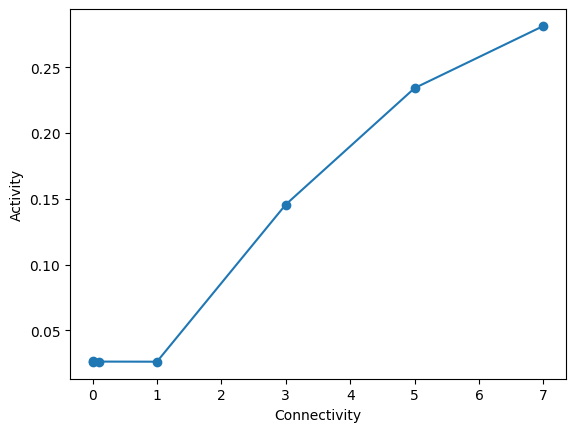

In [65]:
plt.plot(K_list, ave_list, marker='o')
plt.xlabel("Connectivity")
plt.ylabel("Activity")
plt.savefig('connectivity_activity.png', dpi=300)

In [31]:
all_test = []
for K in K_list:
    with open(f"/Users/compneuro1/Documents/projects/SOC/results/Ks_correlation_test/K{K}.pkl", "rb") as f:
        test_new= pickle.load(f)
        all_test.append(test_new)

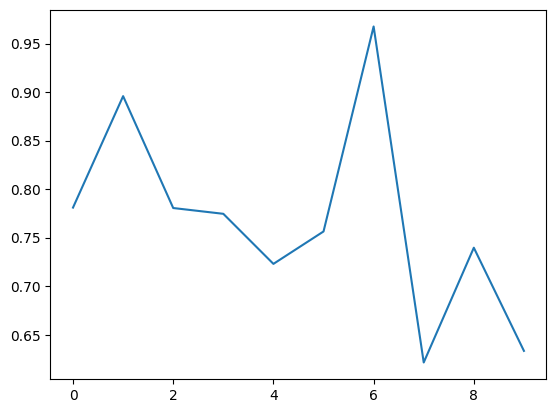

In [75]:
plt.plot(correlation_list)

In [33]:
ave_correlation = []
for i in all_test:
    # ave_correlation.append(np.array(i['correlation'])[-1000:].mean())
    ave_correlation.append(i['correlation'])

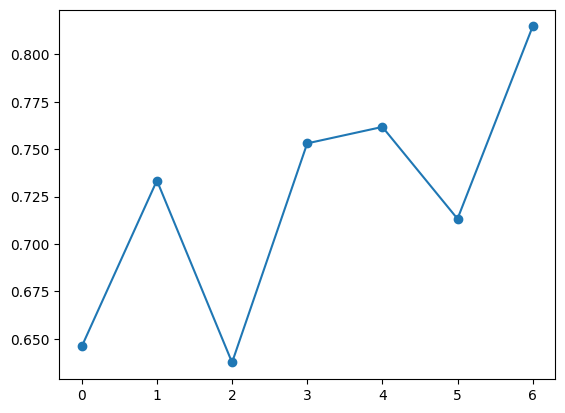

In [36]:
plt.plot(ave_correlation, marker='o')

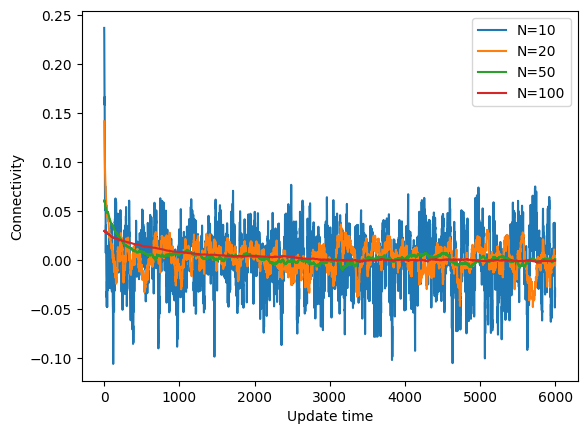

In [35]:

for i in range(len(all_test)):
    plt.plot(all_test[i]['connectivity'], label=f"N={N_list[i]}")

plt.xlabel("Update time")
plt.ylabel("Connectivity")
plt.legend()
plt.savefig("N_list_connectivity.png", dpi=300)

In [38]:
ave_connect = []

for i in range(len(all_test)):
    ave_connect.append(all_test[i]['connectivity'])

In [39]:
ave_connect = np.array(ave_connect)

In [40]:
ave_connect.shape

(4, 6000)

In [42]:
mean_last_100 = ave_connect[:,-100:].mean(axis=1)

In [43]:
mean_last_100

array([ 6.0763890e-03, -5.5010729e-03, -2.9138047e-05, -8.3853008e-04],
      dtype=float32)

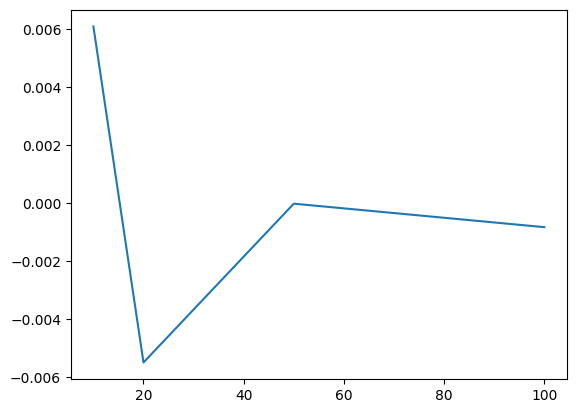

In [44]:
plt.plot(N_list, mean_last_100)

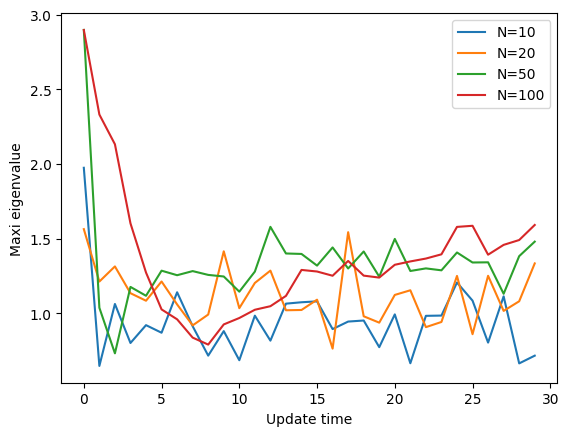

In [36]:
for i in range(len(all_test)):
    plt.plot(all_test[i]['lamb'], label=f"N={N_list[i]}")

plt.xlabel("Update time")
plt.ylabel("Maxi eigenvalue")
# plt.title("Maximum eigenvalue")
plt.legend()
plt.savefig("N_list_eigen.png", dpi=300)

<Axes: >

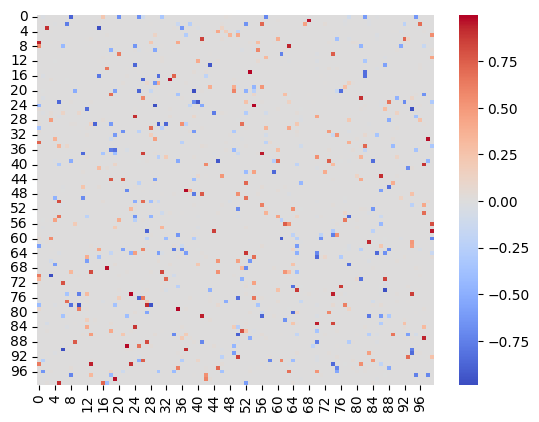

In [95]:
sns.heatmap(
        K1_all['weight'][-1],
        cmap="coolwarm",
        center=0,
        # vmin=-0.15,
        # vmin=-0.2,
        # vmax=1.0    
    )

In [82]:
weights = np.abs(weights)

In [105]:
new_weights = K4_0_1_all["weight"]

In [108]:
new_weights.shape

(3000, 100, 100)

In [109]:
weights_sum = new_weights.sum(axis=(1,2))

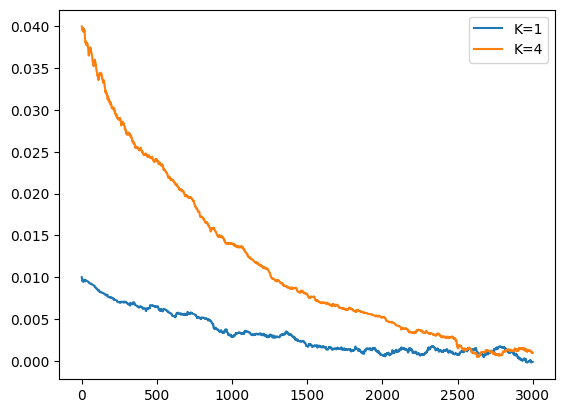

In [ ]:
plt.plot(K1_all["connectivity"], label="K=1")
plt.plot(K4_all["connectivity"], label="K=4")
plt.legend()

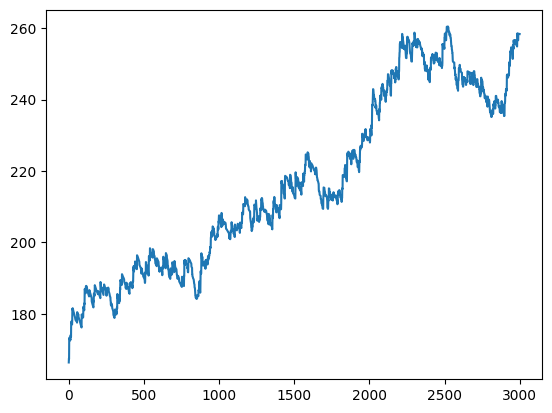

In [85]:
plt.plot(weights_sum)

## Static

In [30]:
Ns = [10, 20, 50, 100, 200, 400, 1000]

In [12]:
all_test = []
for i in params:
    with open(f"/Users/compneuro1/Documents/projects/SOC/static/K_list_N{i}.pkl", "rb") as f:
        test_new= pickle.load(f)
        all_test.append(test_new)
        
Ks_list = []
As_list = []
for i in range(len(all_test)):
    Ks_list.append(all_test[i]["ave_Ks"])
    As_list.append(all_test[i]["ave_As"])


Ks_list = np.array(Ks_list)
As_list = np.array(As_list)


In [14]:
As_list.shape

(7, 41)

In [20]:
both_lists = np.stack([Ks_list, As_list], axis=1)

In [21]:
both_lists.shape

(7, 2, 41)

L = 0.7668225215235773
k = 172.77038588678866
x0 = 0.028151941013704957
b = -0.030328268446454424


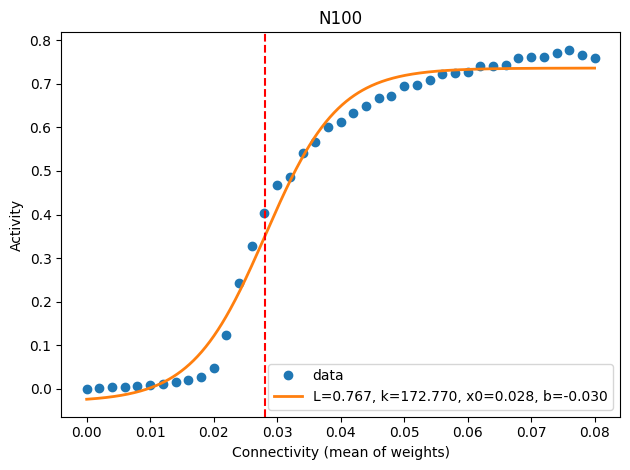

In [4]:
from scipy.optimize import curve_fit

x = test['ave_Ks']
y = test['ave_As']

# Logistic sigmoid
def sigmoid(x, L, k, x0, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

# Initial guess
p0 = [0.8, 300, 0.014, 0]

# Fit
params, _ = curve_fit(sigmoid, x, y, p0=p0)

L, k, x0, b = params

print("L =", L)
print("k =", k)
print("x0 =", x0)
print("b =", b)

# Smooth curve
x_fit = np.linspace(min(x), max(x), 500)
y_fit = sigmoid(x_fit, *params)

plt.plot(x, y, 'o', label='data')
plt.plot(x_fit, y_fit, '-', linewidth=2, label=f"L={L:.3f}, k={k:.3f}, x0={x0:.3f}, b={b:.3f}")

plt.axvline(x=x0, linestyle='--', color='red')

plt.xlabel("Connectivity (mean of weights)")
plt.ylabel("Activity")

plt.legend()
plt.title("N100")

plt.tight_layout()
# plt.savefig("N100_sig.png", dpi=300)

L = 0.7844782620450057
k = 25.668085639810098
x0 = 0.14762616676318416
b = -0.019967448374231846
L = 0.7778461364063851
k = 62.7851828822404
x0 = 0.07201077618027098
b = -0.02299493075639818
L = 0.7668225215235773
k = 172.77038588678866
x0 = 0.028151941013704957
b = -0.030328268446454424
L = 0.7656077078174304
k = 337.57924770088147
x0 = 0.01430692770733572
b = -0.03331479726297723
L = 0.7558444570497874
k = 693.8186928082142
x0 = 0.007196364663336041
b = -0.03335766735868557
L = 0.7499790781819646
k = 1375.1438484325515
x0 = 0.0036384265081273355
b = -0.033551555161977956
L = 0.7492077680533281
k = 3372.7428061429187
x0 = 0.0014703340235316
b = -0.03505039239335405


/var/folders/v2/7v9psnv97b77q1l543tr9jbw0000gn/T/ipykernel_2037/4046393118.py:3: RuntimeWarning: overflow encountered in exp
  return L / (1 + np.exp(-k * (x - x0))) + b


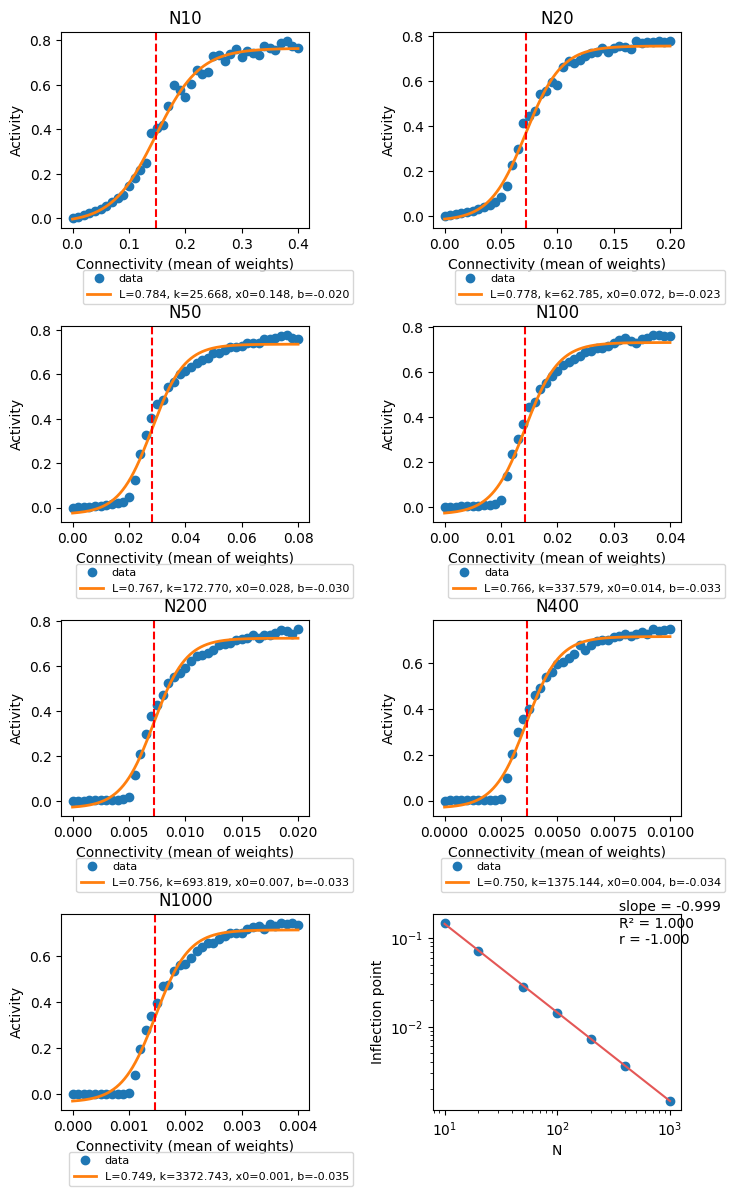

In [51]:
# Logistic sigmoid
def sigmoid(x, L, k, x0, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

# Initial guess
p0 = [0.8, 300, 0.014, 0]



fig, axes = plt.subplots(4,2, figsize=(8,14))

plt.subplots_adjust(
    wspace=0.5,
    hspace=0.5
)

axes = axes.flatten()
x0_list = []

for i, ax in enumerate(axes[:-1]):

    x = both_lists[i][0]
    y = both_lists[i][1]

    params, _ = curve_fit(sigmoid, x, y, p0=p0)

    L, k, x0, b = params

    x0_list.append(x0)

    print("L =", L)
    print("k =", k)
    print("x0 =", x0)
    print("b =", b)

    # Smooth curve
    x_fit = np.linspace(min(x), max(x), 500)
    y_fit = sigmoid(x_fit, *params)

    ax.plot(x, y, 'o', label='data')
    ax.plot(x_fit, y_fit, '-', linewidth=2, label=f"L={L:.3f}, k={k:.3f}, x0={x0:.3f}, b={b:.3f}")
    

    ax.axvline(x=x0, linestyle='--', color='red')

    ax.set_xlabel("Connectivity (mean of weights)")
    ax.set_ylabel("Activity")

    ax.legend()
    ax.legend(loc='center right', bbox_to_anchor=(1.2, -0.3), fontsize=8)
    ax.set_title(f"N{Ns[i]}")


axes[-1].scatter(Ns, x0_list)

axes[-1].set_xscale("log")
axes[-1].set_yscale("log")

axes[-1].set_xlabel("N")
axes[-1].set_ylabel("Inflection point")


log_x = np.log10(Ns)
log_y = np.log10(x0_list)


# regression
slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)

# predicted curve
x_fit = np.linspace(min(Ns), max(Ns), 200)
y_fit = 10**intercept * x_fit**slope

# R^2
r2 = r_value**2

# plot

axes[-1].plot(x_fit, y_fit, color="#E45756")


# show stats on plot
axes[-1].text(
    0.75, 0.85,
    f"slope = {slope:.3f}\nR² = {r2:.3f}\nr = {r_value:.3f}",
    transform=plt.gca().transAxes
)
    # ax.tight_layout()

plt.savefig("static_Ns.png", dpi=300)

In [94]:
activities = test['activity_list']

In [95]:
len(activities)

300

In [96]:
sum(activities)/len(activities)

0.7678013333333336

## Weights changes

In [4]:
weights = test['weight']

In [5]:
weights = np.array(weights)

In [6]:
weights.shape

(3000, 100, 100)

In [7]:
diff_w = weights[-5] - weights[-4]

In [8]:
diff_w.shape

(100, 100)

In [8]:
diff_list = []
for i in range(weights.shape[0]):
    if i != 0:
        diff = weights[i] - weights[i-1]

        diff_list.append(np.count_nonzero(diff))

Text(0, 0.5, 'Sum of changed neurons')

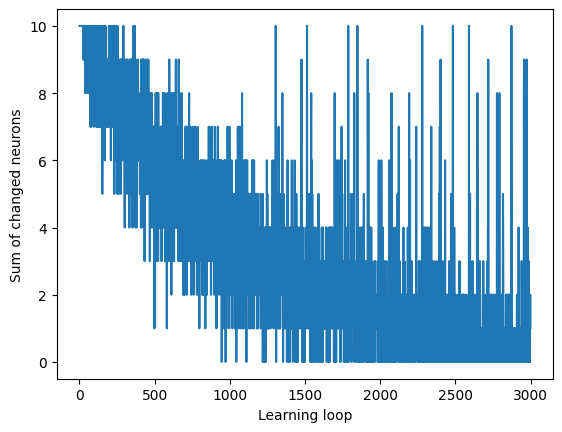

In [9]:
%matplotlib inline
plt.plot(diff_list)
plt.xlabel("Learning loop")
plt.ylabel("Sum of changed neurons")
# plt.savefig('weight_change.png', dpi=300)

<Axes: >

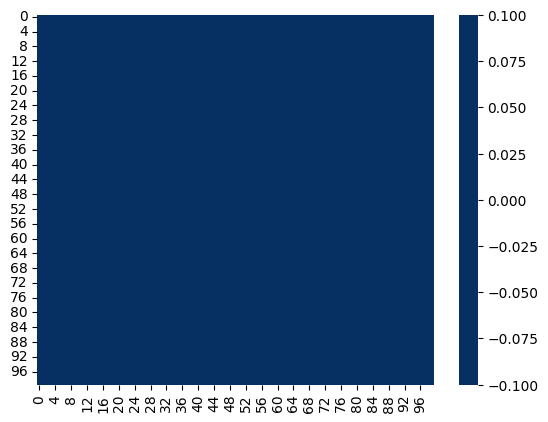

In [59]:
sns.heatmap(
    diff_w,
    cmap='RdBu_r',
    center=0
    )

In [33]:
np.min(weights[2999])

-0.13265155

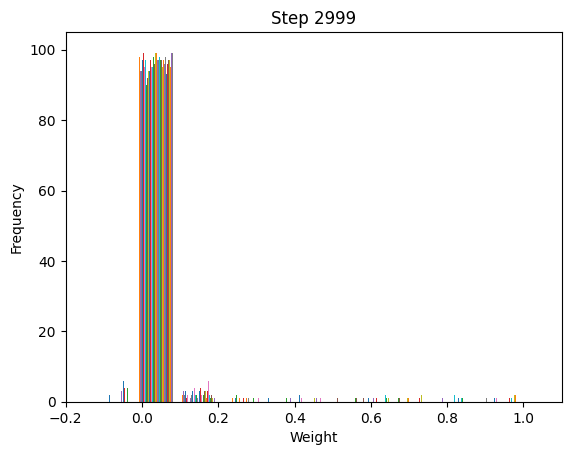

In [51]:
idx = 2999
plt.hist(weights[idx], bins=10)
plt.xlim(-0.2, 1.1)
plt.ylim(0, 105)
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.title(f"Step {idx}")
plt.savefig(f"weight_dist_{idx}.png", dpi=300)

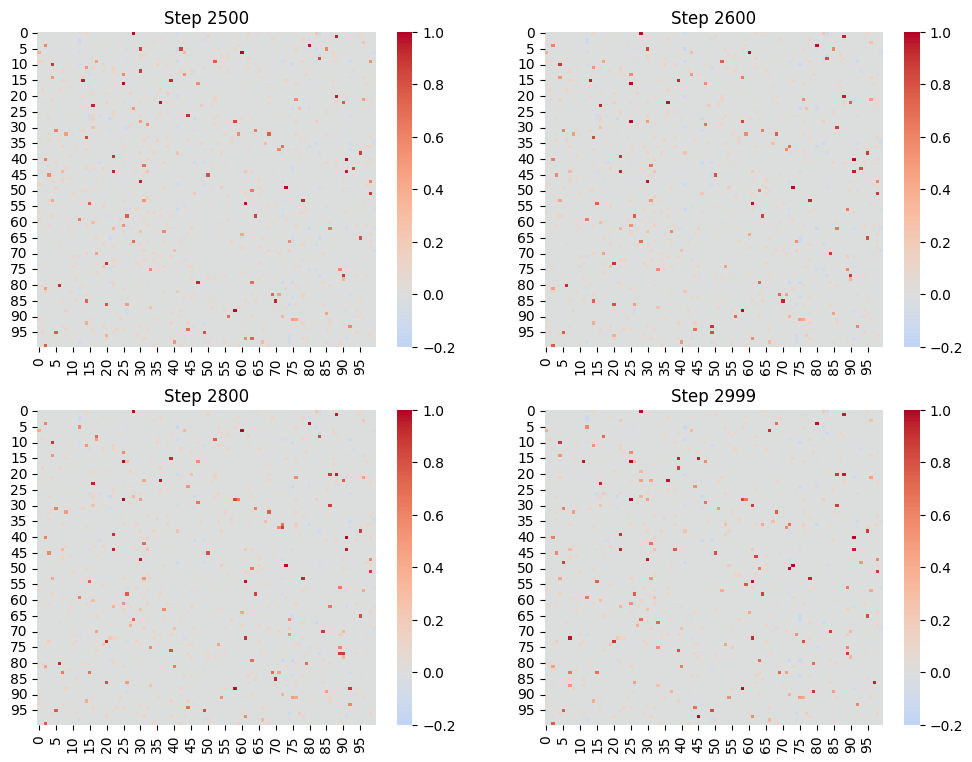

In [29]:
fig, axes = plt.subplots(2,2, figsize=(12,9))
axes = axes.flatten()

steps = [2500, 2600, 2800, 2999]

for i, data in enumerate(weights[steps]):
    sns.heatmap(
        data,
        ax=axes[i],
        cmap="coolwarm",
        center=0,
        # vmin=-0.15,
        vmin=-0.2,
        vmax=1.0    
    )

    axes[i].set_title(f"Step {steps[i]}")
plt.savefig("weights_4.png", dpi=300)

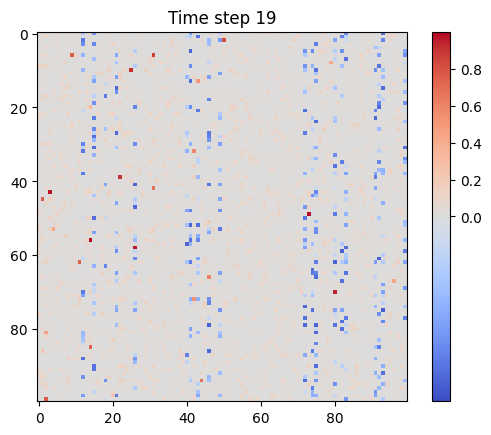

In [18]:
# import matplotlib
# matplotlib.use("TkAgg") 
fig, ax = plt.subplots()
from matplotlib.colors import TwoSlopeNorm

norm = TwoSlopeNorm(vmin=-0.15, vcenter=0, vmax=1.0)

# initial frame
im = ax.imshow(weights[1500], cmap="coolwarm", norm=norm, animated=True)
plt.colorbar(im, ax=ax)

def update(frame):
    im.set_array(weights[frame+1500])
    ax.set_title(f"Time step {frame}")
    return [im]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=20,
    interval=100,   # ms between frames
    blit=True
)

ani.save("weights.gif", writer="pillow", fps=10)

# plt.show()

## Fire visualization

In [32]:
fire_data = test["fire_data"]

In [46]:
fire = []
fire_points = []
run_points = []

i = 0
for f in fire_data:
    for r in f:
        for c in r:
            # fire.append(c.sum().item())
            fire.append(c)
            i+=1
        run_points.append(i)
    fire_points.append(i)

In [48]:
fire = np.array(fire)

In [49]:
fire.shape

(630, 100)

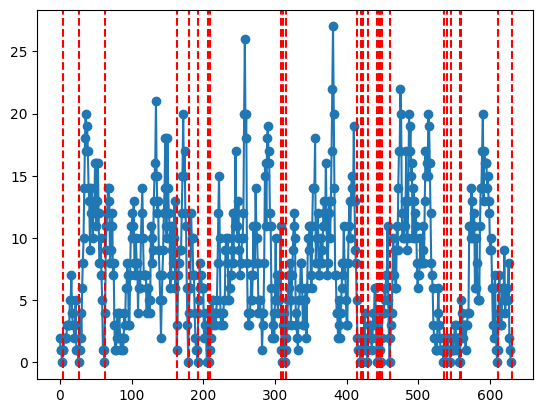

In [45]:
plt.plot(fire, marker='o')
for i in run_points:
    plt.axvline(x=i, color='red', linestyle='--')

In [50]:
with open(f'K4_fire.pkl', 'wb') as f:
    pickle.dump(fire, f)

In [ ]:
fire = np.array(fire)

In [54]:
fire.shape

(300, 100)

In [43]:
fire.sum(axis=1)

array([ 2.,  4.,  4.,  7.,  4.,  5.,  3.,  4.,  4.,  6.,  5.,  8.,  8.,
        4.,  8.,  5.,  5.,  3.,  5.,  5.,  7.,  4.,  6.,  8.,  8.,  7.,
        7., 10.,  9., 13., 16., 14., 17., 12., 18., 13., 17., 11., 18.,
       12.,  9.,  8.,  6.,  8.,  5.,  8., 11., 13., 10.,  8., 14., 11.,
        7.,  9., 10.,  6.,  3.,  0.], dtype=float32)

In [55]:
with open(f'test_fire.pkl', 'wb') as f:
    pickle.dump(fire, f)

In [7]:
fire_sum = []
for i in fire_data[0]:
    temp = []
    for j in i:
        temp.append(sum(j).item())
    fire_sum.append(temp)


(80.0, 110.0)

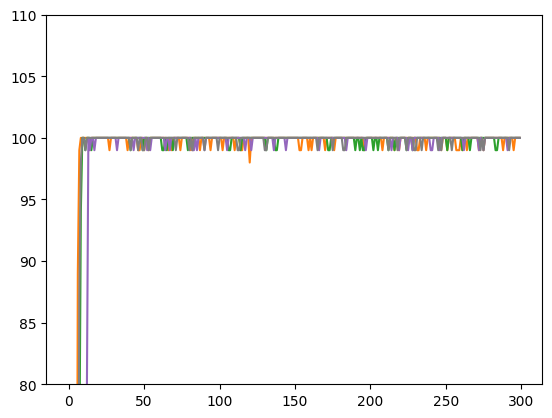

In [ ]:
for i in fire_sum:
    plt.plot(i, label=)
plt.ylim(80,110)

In [21]:
p_N100 = [t/200 for t in N100]
p_N200 = [t/200 for t in N200]

In [ ]:
from scipy.optimize import curve_fit

# sigmoid function
def sigmoid(x, L, k, x0):
    return L / (1 + np.exp(-k*(x - x0)))


# initial guesses
initial_guess = [max(new_test), 1, np.median(new_test)]

# fit
params, _ = curve_fit(sigmoid, x, new_test, p0=initial_guess)

L, k, x0 = params

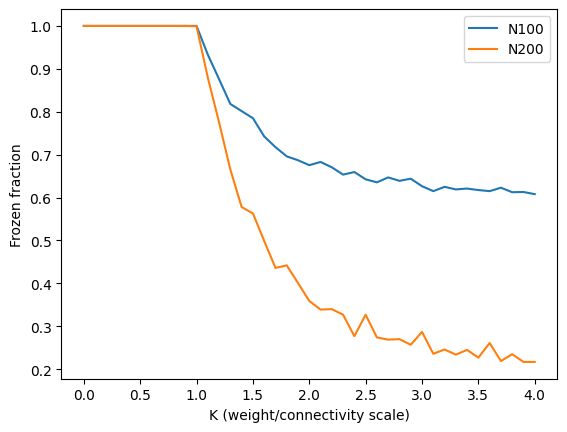

In [22]:
plt.plot(x, p_N100, label="N100")
plt.plot(x, p_N200, label="N200")
# plt.plot(x, sigmoid(x, L, k, x0))
plt.xlabel('K (weight/connectivity scale)')
plt.ylabel("Frozen fraction")
plt.legend()
# plt.savefig("frozen.png", dpi=300)

In [289]:
fire_data = test["fire_data"]

In [290]:
fire_data = np.array(fire_data)

In [291]:
fire_data.shape

(1000, 200)

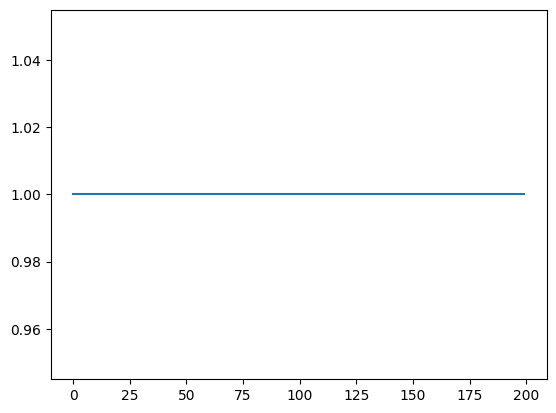

In [292]:
plt.plot(fire_data[998])

In [293]:
# last = fire_data[-3000:]
# active = (last > 0.0).any(axis=0)
# dead = ~active

In [294]:
# dead.sum().item()

In [295]:
fire_sum = np.sum(fire_data, axis=1)

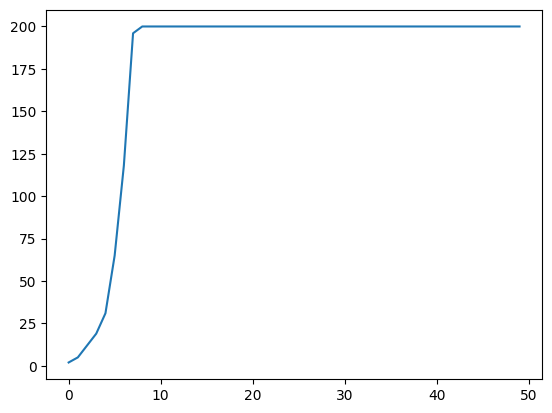

In [297]:
plt.plot(fire_sum[:50])

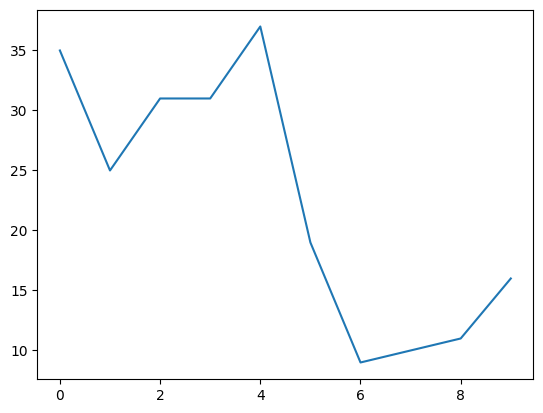

In [17]:
plt.plot(fire_sum[4000:4010])

In [6]:
N_list = [10, 20, 50, 100, 200, 400, 1000]

In [11]:
N_list[0]

10

In [13]:
len(test)

7

In [13]:
test["connectivity"]

[tensor(0.0399),
 tensor(0.0399),
 tensor(0.0398),
 tensor(0.0397),
 tensor(0.0396),
 tensor(0.0395),
 tensor(0.0394),
 tensor(0.0393),
 tensor(0.0392),
 tensor(0.0391),
 tensor(0.0391),
 tensor(0.0390),
 tensor(0.0390),
 tensor(0.0389),
 tensor(0.0388),
 tensor(0.0387),
 tensor(0.0387),
 tensor(0.0386),
 tensor(0.0385),
 tensor(0.0384),
 tensor(0.0384),
 tensor(0.0383),
 tensor(0.0382),
 tensor(0.0381),
 tensor(0.0380),
 tensor(0.0379),
 tensor(0.0379),
 tensor(0.0377),
 tensor(0.0377),
 tensor(0.0376),
 tensor(0.0375),
 tensor(0.0374),
 tensor(0.0374),
 tensor(0.0373),
 tensor(0.0372),
 tensor(0.0371),
 tensor(0.0371),
 tensor(0.0370),
 tensor(0.0369),
 tensor(0.0369),
 tensor(0.0368),
 tensor(0.0367),
 tensor(0.0367),
 tensor(0.0366),
 tensor(0.0365),
 tensor(0.0365),
 tensor(0.0364),
 tensor(0.0363),
 tensor(0.0362),
 tensor(0.0361),
 tensor(0.0361),
 tensor(0.0360),
 tensor(0.0360),
 tensor(0.0359),
 tensor(0.0358),
 tensor(0.0358),
 tensor(0.0357),
 tensor(0.0356),
 tensor(0.0356

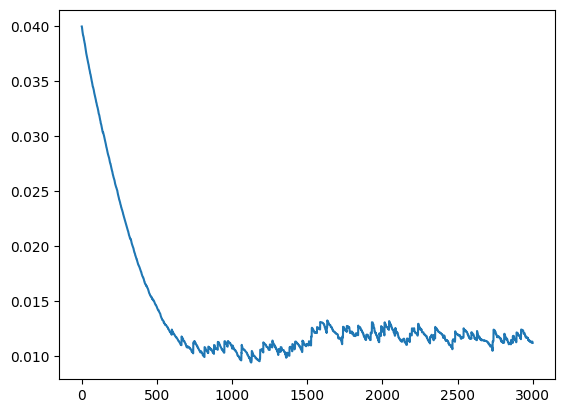

In [14]:
plt.plot(test["connectivity"])

In [ ]:
ave_connectivity = []
for i in range(len(test)):
    last = test[i]["connectivity"]
    ave_connectivity.append(sum(last)/len(last))

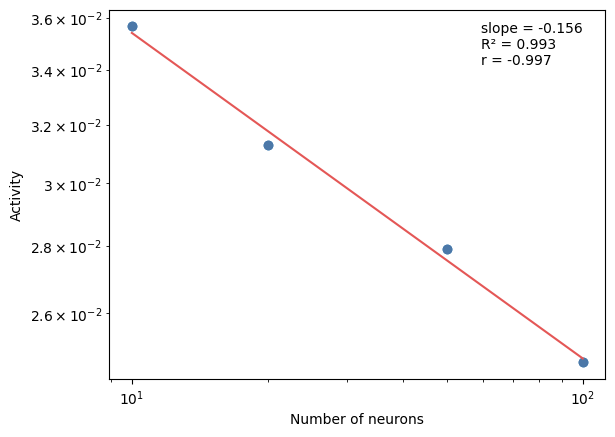

In [224]:
x = N_list
# y = ave_connectivity
y = activation_list

plt.scatter(x, y)
plt.xscale("log")
plt.yscale("log")

log_x = np.log10(x)
log_y = np.log10(y)

# regression
slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)

# predicted curve
x_fit = np.linspace(min(x), max(x), 200)
y_fit = 10**intercept * x_fit**slope

# R^2
r2 = r_value**2

# plot
plt.scatter(x, y, color="#4C78A8")
plt.plot(x_fit, y_fit, color="#E45756")

plt.xscale("log")
plt.yscale("log")

# show stats on plot
plt.text(
    0.75, 0.85,
    f"slope = {slope:.3f}\nR² = {r2:.3f}\nr = {r_value:.3f}",
    transform=plt.gca().transAxes
)


plt.xlabel("Number of neurons")
plt.ylabel("Activity")



plt.savefig("activity_number.png", dpi=300)


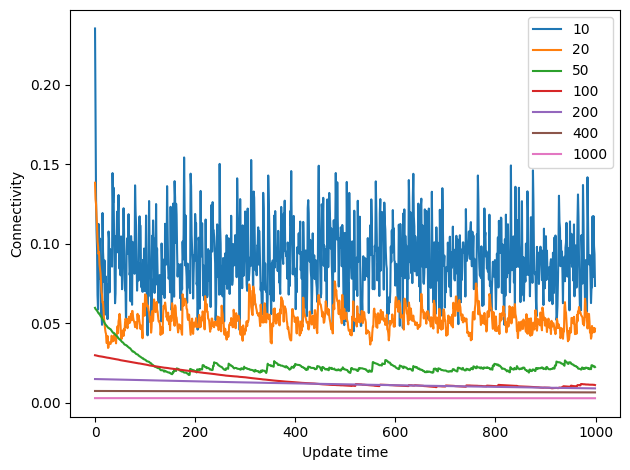

In [ ]:
for i in range(len(test)):
    plt.plot(test[i]["connectivity"][:1000], label=N_list[i])

plt.xlabel("Update time")
plt.ylabel("Connectivity")
plt.tight_layout()
plt.legend()
# plt.savefig("Ns.png", dpi=300)

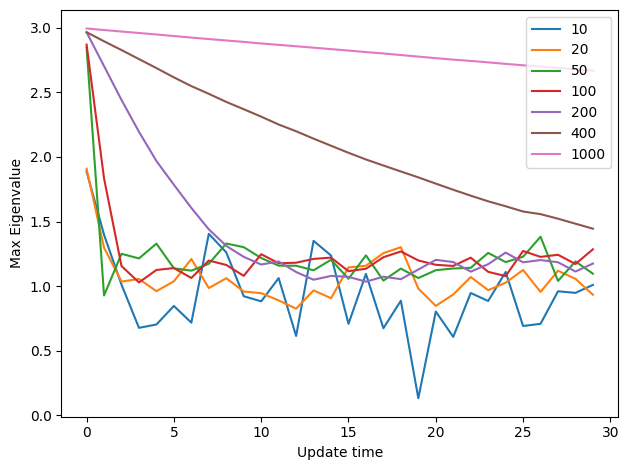

In [47]:
for i in range(len(test)):
    plt.plot(test[i]["lamb"][:], label=N_list[i])

plt.xlabel("Update time")
plt.ylabel("Max Eigenvalue")
plt.tight_layout()
plt.legend()
plt.savefig("singular.png", dpi=300)

In [6]:
test = np.array(connectivity["fire_data"])

In [7]:
test.shape

(738765, 200)

In [4]:
len(connectivity["lamb"])

1

In [9]:
x = np.linspace(0,2500,13)

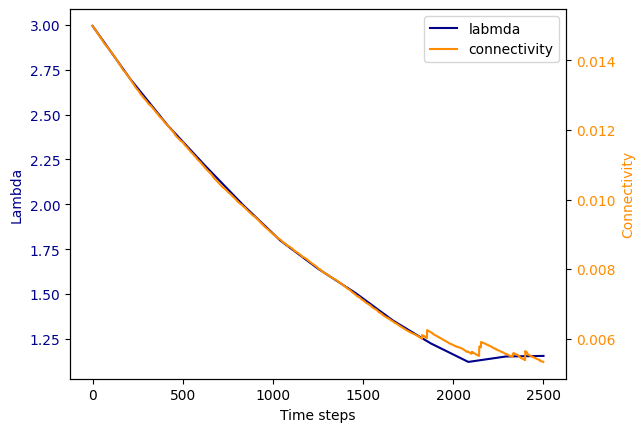

In [10]:
fig, ax1 = plt.subplots()

line1, = ax1.plot(x, connectivity["lamb"], label="labmda", color="darkblue")
ax1.set_xlabel("Time steps")
ax1.set_ylabel("Lambda", color="darkblue")
ax1.tick_params(axis="y", labelcolor="darkblue")

ax2 = ax1.twinx()
line2, = ax2.plot(connectivity["connectivity"], label="connectivity", color="darkorange")
ax2.set_ylabel("Connectivity", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right")

# fig.savefig("connect_lambda.png", dpi=300)

In [152]:
connectivity = np.array(connectivity)

In [153]:
connectivity.shape

(729152, 200)

In [162]:
test = connectivity[610000:611000]

In [11]:
test_sum = test.sum(axis=0)

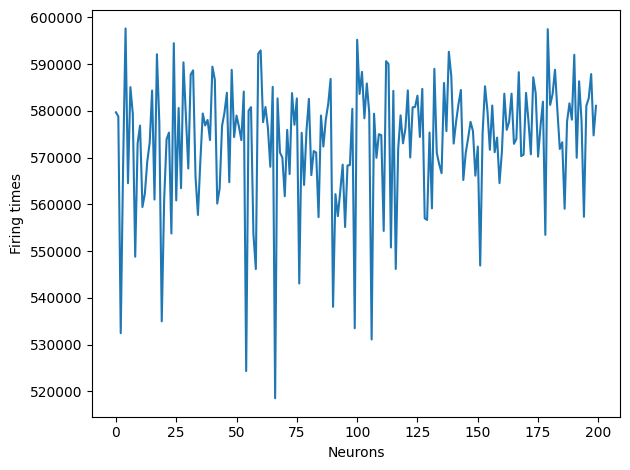

In [12]:
plt.plot(test_sum)
plt.xlabel('Neurons')
plt.ylabel('Firing times')
plt.tight_layout()
# plt.savefig("frozen.png", dpi=300)

In [105]:
small_fire_data = connectivity[:1000]

In [95]:
sum_fire = connectivity.sum(axis=-1)

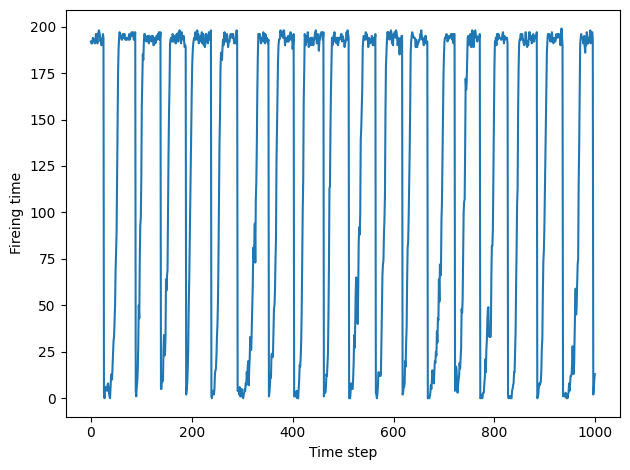

In [149]:
plt.plot(sum_fire[610000:611000])
plt.xlabel('Time step')
plt.ylabel('Fireing time')
plt.tight_layout()
plt.savefig("fire_patterns_middle.png", dpi=300)

In [106]:
small_fire_data = np.array(small_fire_data)

In [107]:
with open(f'fire_data.pkl', 'wb') as f:
    pickle.dump(small_fire_data, f)

In [85]:
len(connectivity)

729152

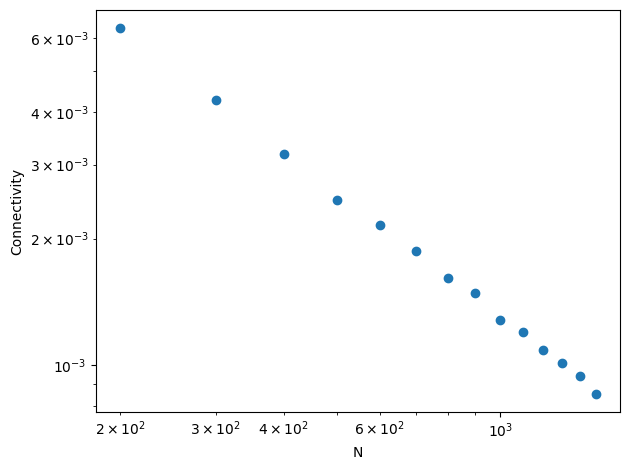

In [144]:
plt.scatter(nums, connectivity["connectivity"])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('Connectivity')
plt.tight_layout()
plt.savefig("without_N_Connect.png", dpi=300)

In [141]:
np.log(connectivity["lambdass"][0][-1])

0.21127173504869035

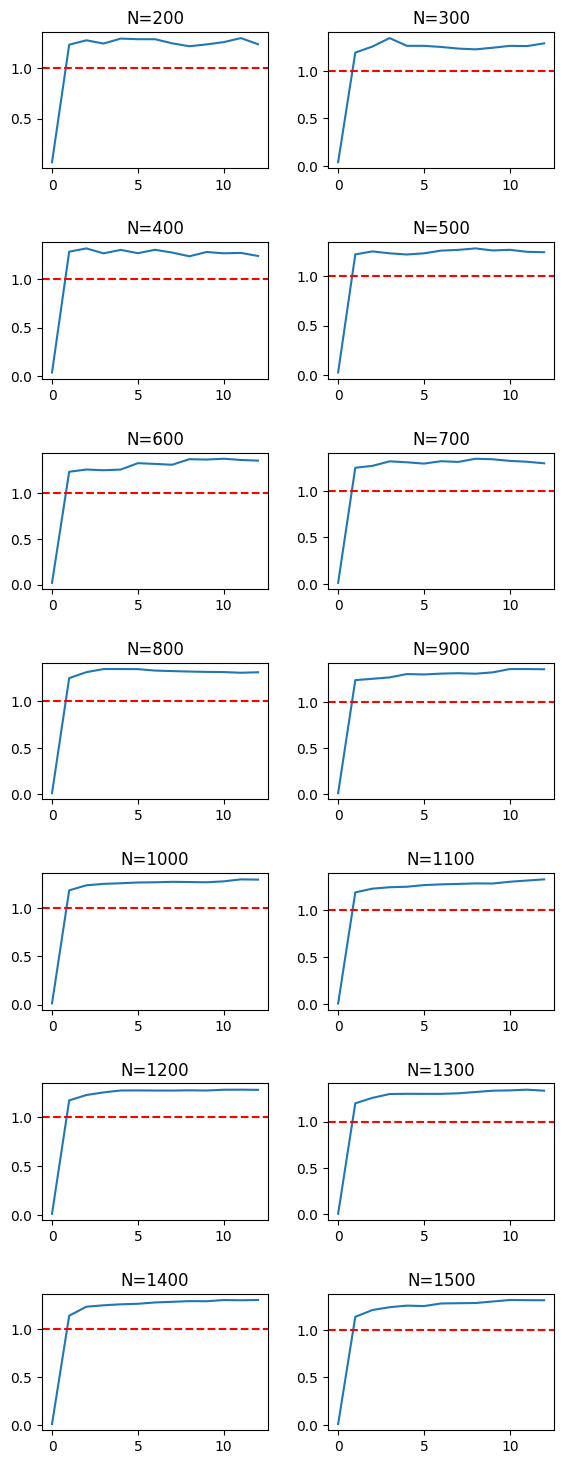

In [142]:
fig, axes = plt.subplots(7,2, figsize=(6, 15))

for i, ax in enumerate(axes.flatten()[:14]):
    ax.plot(connectivity["lambdass"][i])
    ax.set_title(f"N={nums[i]}")
    # ax.set_ylim(0,5)
    ax.axhline(y=1, linestyle="--", color="red")

plt.tight_layout(pad=2.0)
plt.savefig("without_N_Lambda.png", dpi=300)

In [49]:
len(connectivity["lambdass"])

14

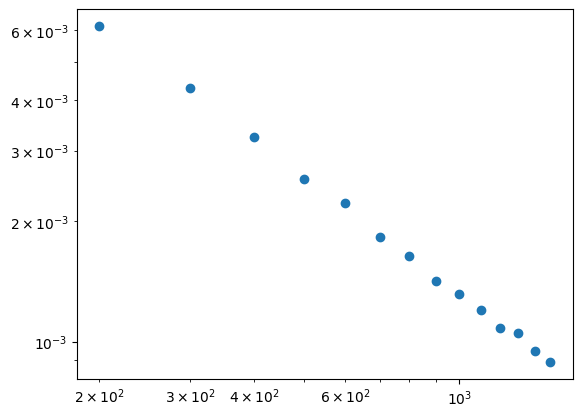

In [38]:
plt.scatter(nums, connectivity)
plt.xscale('log')
plt.yscale('log')

In [18]:
connectivity = np.array(connectivity)

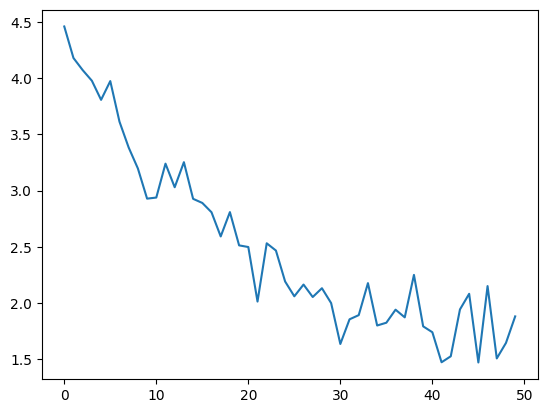

In [31]:
plt.plot(connectivity["train_losses"])

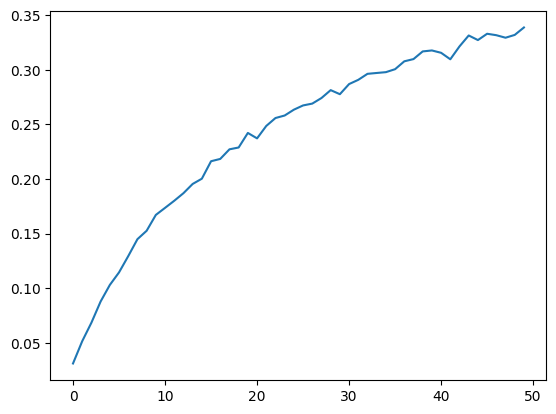

In [32]:
plt.plot(connectivity["val_accuracies"])

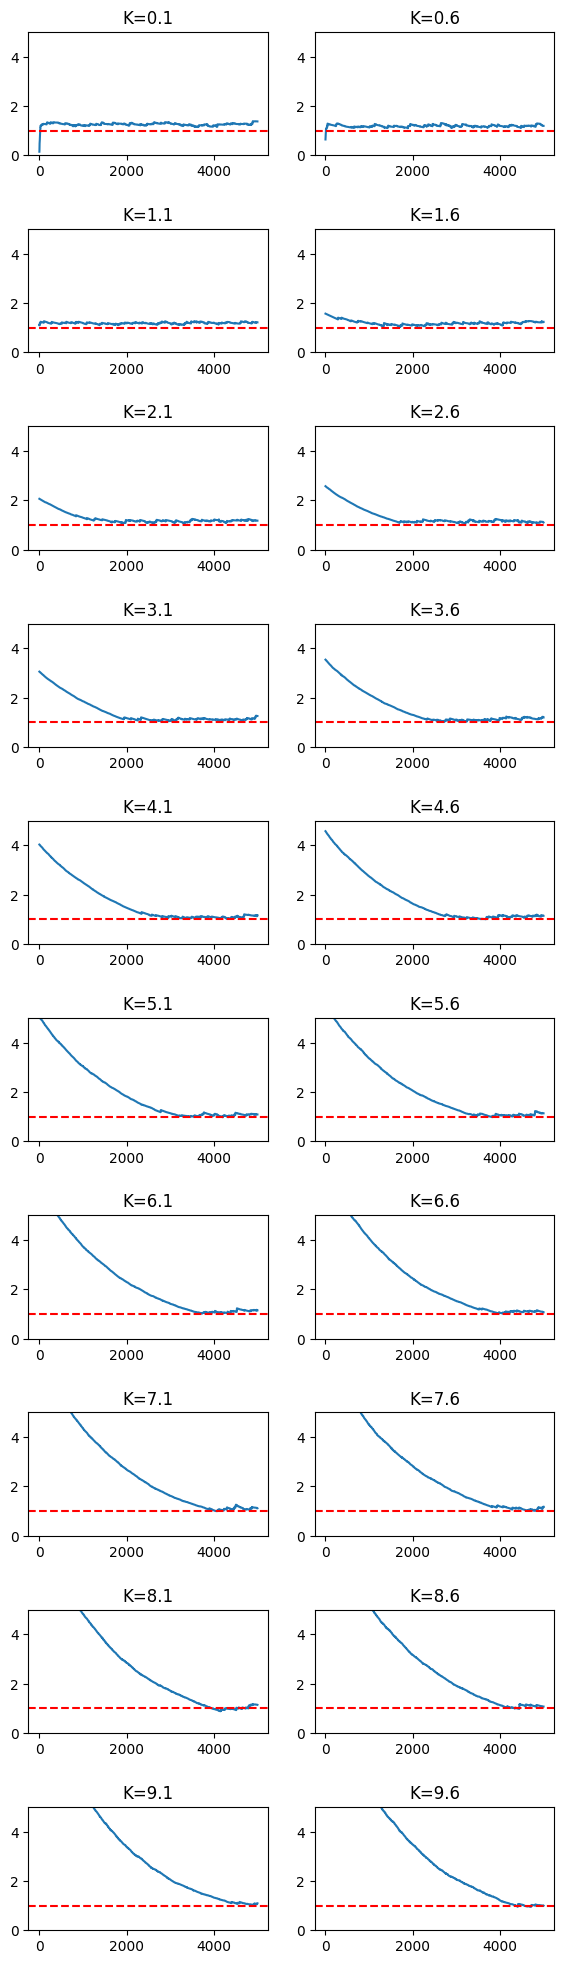

In [32]:
fig, axes = plt.subplots(10,2, figsize=(6, 20))
x = np.arange(0.1, 10, 0.5)

for i, ax in enumerate(axes.flatten()):
    ax.plot(connectivity[i])
    ax.set_title(f"K={x[i]}")
    ax.set_ylim(0,5)
    ax.axhline(y=1, linestyle="--", color="red")

plt.tight_layout(pad=2.0)
plt.savefig("ks.png", dpi=300)

In [9]:
# nums = np.arange(200, 1300, 100)
nums = np.arange(200, 1600, 100)

In [7]:
nums

array([ 200,  300,  400,  500,  600,  700,  800,  900, 1000, 1100, 1200])

In [3]:
connectivity

[tensor(0.0072),
 tensor(0.0096),
 tensor(0.0091),
 tensor(0.0082),
 tensor(0.0073),
 tensor(0.0064),
 tensor(0.0058),
 tensor(0.0052),
 tensor(0.0048),
 tensor(0.0044),
 tensor(0.0040)]

In [16]:
a, b = np.polyfit(nums[2:], connectivity[2:], 1)

In [17]:
y_pred = a*nums[2:] + b

In [18]:
a

-5.1858683582395295e-06

In [21]:
log_nums = np.log(nums[1:])
log_c = np.log(connectivity[1:])

In [26]:
pred = log_nums*result.slope + result.intercept

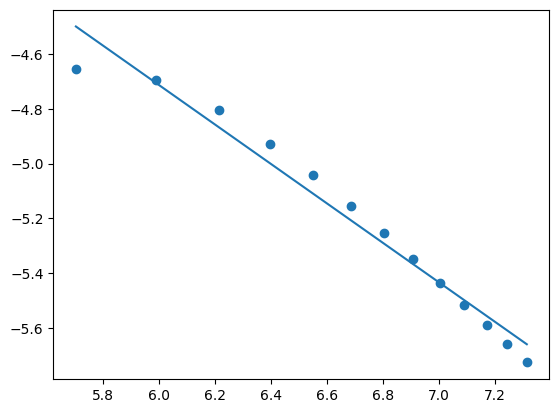

In [28]:
plt.scatter(log_nums, log_c)
plt.plot(log_nums, pred)

In [24]:
from scipy.stats import linregress

result = linregress(log_nums, log_c)

In [25]:
result

LinregressResult(slope=-0.7205522587999688, intercept=-0.3899918096762187, rvalue=-0.984413357555503, pvalue=1.1864910214402458e-09, stderr=0.038813606682343404, intercept_stderr=0.2606471561605881)

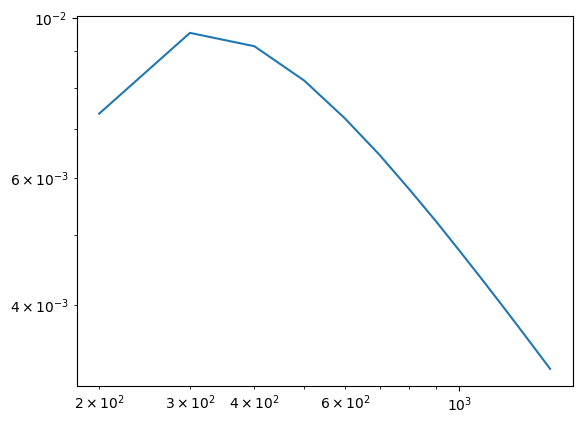

In [20]:
plt.plot(nums[:], connectivity[:])
# plt.plot(nums[2:], y_pred)
plt.xscale('log')
plt.yscale('log')
